# Phiên bản khác multi naive bayes

In [1]:
# Hate Speech Detection - TFIDF + Multinomial Naive Bayes (MultinomialNB)
# - Fit trên train.csv
# - Tune hyperparam dựa trên dev.csv (PredefinedSplit)
# - Chấm điểm 1 lần trên test.csv
# Dữ liệu đã preprocessing sẵn, cột: free_text, label_id

import os
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    f1_score, accuracy_score,
    classification_report, confusion_matrix
)
from scipy.stats import loguniform


# ===================== CONFIG =====================
TRAIN_PATH = "/home/uit2023/LuuTru/Thuchd/cs221/CS221_NLP_SA/UIT-ViHSD-preprocessed/train.csv"
DEV_PATH   = "/home/uit2023/LuuTru/Thuchd/cs221/CS221_NLP_SA/UIT-ViHSD-preprocessed/dev.csv"
TEST_PATH  = "/home/uit2023/LuuTru/Thuchd/cs221/CS221_NLP_SA/UIT-ViHSD-preprocessed/test.csv"

TEXT_COL  = "free_text"
LABEL_COL = "label_id"

SCORING = "f1_macro"
SAVE_MODEL_PATH = "./models/final_best_mnb_tfidf.joblib"
SAVE_INFO_PATH  = "./models/final_best_mnb_tfidf_info.json"

RANDOM_STATE = 42
N_ITER_WORD = 60
N_ITER_CHAR = 60

# alpha của NB (Laplace smoothing)
ALPHA_DIST = loguniform(1e-3, 1e1)


# ===================== LOAD =====================
def load_xy(path):
    df = pd.read_csv(path).dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[TEXT_COL]  = df[TEXT_COL].astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df[TEXT_COL].tolist(), df[LABEL_COL].tolist()

X_train, y_train = load_xy(TRAIN_PATH)
X_dev,   y_dev   = load_xy(DEV_PATH)
X_test,  y_test  = load_xy(TEST_PATH)

def overlap_count(a, b):
    sa, sb = set(a), set(b)
    return len(sa & sb)

print("Overlap train-dev :", overlap_count(X_train, X_dev))
print("Overlap train-test:", overlap_count(X_train, X_test))
print("Overlap dev-test  :", overlap_count(X_dev, X_test))


# ===================== PIPELINE TEMPLATE =====================
def make_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(sublinear_tf=False,smooth_idf=False)),
        ("clf", MultinomialNB())
    ])

def eval_and_print(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("f1_macro:", f1_score(y_true, y_pred, average="macro"))
    print("acc     :", accuracy_score(y_true, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nReport:\n", classification_report(y_true, y_pred, digits=4))


# ===================== PredefinedSplit: train=-1, dev=0 =====================
X_train_dev = X_train + X_dev
y_train_dev = y_train + y_dev
test_fold = [-1] * len(X_train) + [0] * len(X_dev)
ps = PredefinedSplit(test_fold=test_fold)


# ===================== PARAM DISTRIBUTIONS =====================
# NOTE:
# - MultinomialNB phù hợp với feature >= 0 (TF-IDF ok).
# - "tfidf__norm" để None hoặc "l2" đều được.
param_dist_word = {
    "tfidf__analyzer": ["word"],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    # "tfidf__use_idf": [True, False],
    # "tfidf__norm": ["l2", None],
    # "tfidf__binary": [False, True],
    "tfidf__max_features": [50000, 100000, None],

    "clf__alpha": ALPHA_DIST,
    "clf__fit_prior": [True, False],
}

# param_dist_char = {
#     "tfidf__analyzer": ["char_wb"],
#     "tfidf__ngram_range": [(3, 5), (4, 6)],
#     "tfidf__min_df": [1, 2, 5],
#     "tfidf__max_df": [0.9, 0.95, 1.0],
#     #"tfidf__use_idf": [True, False],
#     # "tfidf__norm": ["l2", None],
#     # "tfidf__binary": [False, True],
#     "tfidf__max_features": [50000, 100000, None],

#     "clf__alpha": ALPHA_DIST,
#     "clf__fit_prior": [True, False],
# }


# ===================== RANDOMIZED SEARCH (tune theo DEV) =====================
def run_random_search(param_dist, n_iter, tag):
    rs = RandomizedSearchCV(
        estimator=make_pipeline(),
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=SCORING,
        cv=ps,                 # validate trên dev
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_STATE,
        refit=False,           # không refit train+dev để tránh “dính dev”
        error_score=np.nan
    )
    rs.fit(X_train_dev, y_train_dev)
    print(f"\n[{tag}] best_dev_score({SCORING}) = {rs.best_score_}")
    print(f"[{tag}] best_params = {rs.best_params_}")
    return rs.best_score_, rs.best_params_

word_score, word_params = run_random_search(param_dist_word, N_ITER_WORD, "WORD")
#char_score, char_params = run_random_search(param_dist_char, N_ITER_CHAR, "CHAR")

# if char_score >= word_score:
#     best_params = char_params
#     best_dev_score = char_score
#     best_tag = "CHAR"
# else:
best_params = word_params
best_dev_score = word_score
best_tag = "WORD"

print("\n===== BEST (by DEV via RandomizedSearchCV) =====")
print("best_tag      :", best_tag)
print("best_dev_score:", best_dev_score)
print("best_params   :", best_params)


# ===================== Fit on TRAIN -> Report DEV =====================
best_model_train = make_pipeline()
best_model_train.set_params(**best_params)
best_model_train.fit(X_train, y_train)

dev_pred = best_model_train.predict(X_dev)
eval_and_print("DEV (train-only fit)", y_dev, dev_pred)


# ===================== FINAL: Fit TRAIN only -> TEST =====================
final_model = make_pipeline()
final_model.set_params(**best_params)

# Fit CHỈ trên TRAIN (không dùng DEV)
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)
eval_and_print("TEST (train-only final)", y_test, test_pred)


# ===================== SAVE =====================
Path(os.path.dirname(SAVE_MODEL_PATH)).mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, SAVE_MODEL_PATH)

info = {
    "model": "TFIDF + MultinomialNB",
    "best_tag": best_tag,
    "best_params": best_params,
    "best_dev_score": float(best_dev_score),
    "test_f1_macro": float(f1_score(y_test, test_pred, average="macro")),
    "test_acc": float(accuracy_score(y_test, test_pred)),
}
with open(SAVE_INFO_PATH, "w", encoding="utf-8") as f:
    json.dump(info, f, ensure_ascii=False, indent=2)

print(f"\nSaved model: {SAVE_MODEL_PATH}")
print(f"Saved info : {SAVE_INFO_PATH}")


Overlap train-dev : 381
Overlap train-test: 897
Overlap dev-test  : 134
Fitting 1 folds for each of 60 candidates, totalling 60 fits
[CV] END clf__alpha=0.7726718477963437, clf__fit_prior=False, tfidf__analyzer=word, tfidf__max_df=0.95, tfidf__max_features=100000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.3s
[CV] END clf__alpha=0.03148911647956861, clf__fit_prior=True, tfidf__analyzer=word, tfidf__max_df=1.0, tfidf__max_features=None, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.3s
[CV] END clf__alpha=0.016480446427978974, clf__fit_prior=False, tfidf__analyzer=word, tfidf__max_df=0.9, tfidf__max_features=50000, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=   0.3s
[CV] END clf__alpha=0.2801635158716261, clf__fit_prior=False, tfidf__analyzer=word, tfidf__max_df=1.0, tfidf__max_features=100000, tfidf__min_df=2, tfidf__ngram_range=(1, 1); total time=   0.3s
[CV] END clf__alpha=0.2975390947349387, clf__fit_prior=False, tfidf__analyzer=word, tfidf__

# show từng bước inferece

In [6]:
# ===================== SHOW TỪNG BƯỚC INFERENCE (1 MẪU MỚI) =====================
# Pipeline: TF-IDF + MultinomialNB (đã train & joblib.dump)
# Chạy file này để in ra:
# (1) Input -> (2) tokenize theo TFIDF -> (3) TF-IDF vector (token, index, idf, tfidf)
# -> (4) NB scores/proba -> (5) đóng góp từng token -> (6) trọng số từ global của model

import joblib
import numpy as np
import pandas as pd

MODEL_PATH = "/home/uit2023/LuuTru/Thuchd/cs221/CS221_NLP_SA/models/final_best_mnb_tfidf.joblib"

def show_one_sample(text_new: str, topk_local: int = 10, topk_global: int = 8):
    pipe = joblib.load(MODEL_PATH)
    tfidf = pipe.named_steps["tfidf"]
    clf   = pipe.named_steps["clf"]

    print("="*90)
    print("0) LOAD PIPELINE OK")
    print("TFIDF params:", {k: getattr(tfidf, k) for k in ["analyzer","ngram_range","min_df","max_df","max_features"] if hasattr(tfidf,k)})
    print("NB params   :", {"alpha": clf.alpha, "fit_prior": clf.fit_prior})
    print("="*90)

    # -------------------------------------------------------------------------
    # 1) INPUT
    # -------------------------------------------------------------------------
    print("\n1) INPUT")
    print("Text:", text_new)

    # -------------------------------------------------------------------------
    # 2) TOKENIZE (đúng theo TFIDF analyzer của sklearn)
    # build_analyzer() sẽ tạo ra list token/ngram đúng như TFIDF dùng khi fit/transform
    # Lưu ý: nếu ngram_range=(1,2) thì tokens có cả bigram dạng "w1 w2"
    # -------------------------------------------------------------------------
    analyzer_fn = tfidf.build_analyzer()
    tokens = analyzer_fn(text_new)

    print("\n2) TOKENIZE (theo TFIDF.build_analyzer())")
    print("Num tokens/ngrams:", len(tokens))
    print("First tokens:", tokens[:min(20, len(tokens))])

    # -------------------------------------------------------------------------
    # 3) TF-IDF TRANSFORM: text -> sparse vector
    # -------------------------------------------------------------------------
    X = tfidf.transform([text_new])  # shape (1, V)
    feat = tfidf.get_feature_names_out()

    idx = X.nonzero()[1]
    vals = X.data  # tf-idf values tương ứng nonzero
    # X.data không chắc cùng thứ tự với idx nếu bạn lấy như trên; an toàn nhất là lấy từng phần tử:
    vals = np.array([X[0, j] for j in idx], dtype=float)

    # IDF cho các feature (nếu use_idf=True)
    if hasattr(tfidf, "idf_"):
        idf_vals = tfidf.idf_[idx]
    else:
        idf_vals = np.ones_like(vals)

    df_tfidf = pd.DataFrame({
        "feature(token/ngram)": feat[idx],
        "vocab_index": idx,
        "idf": idf_vals,
        "tfidf(x_i)": vals,
    }).sort_values("tfidf(x_i)", ascending=False)

    print("\n3) TF-IDF VECTOR (chỉ show các feature xuất hiện trong câu)")
    print(df_tfidf.head(30).to_string(index=False))

    # -------------------------------------------------------------------------
    # 4) NAIVE BAYES: tính score từng lớp và xác suất
    # score(c) = logP(c) + sum_i x_i * logP(w_i|c)
    # -------------------------------------------------------------------------
    jll = clf.class_log_prior_ + X @ clf.feature_log_prob_.T  # shape (1, C)
    scores = np.asarray(jll).ravel()
    pred = int(scores.argmax())
    proba = clf.predict_proba(X)[0]  # softmax/jll normalization trong sklearn

    df_scores = pd.DataFrame({
        "class": list(range(len(scores))),
        "score(log)": scores,
        "proba": proba
    }).sort_values("score(log)", ascending=False)

    print("\n4) MULTINOMIAL NB SCORES / PROBA")
    print(df_scores.to_string(index=False))
    print("=> PREDICTED:", pred)

    # -------------------------------------------------------------------------
    # 5) “TOP TỪ KÉO OUTPUT” (LOCAL CONTRIBUTION theo mẫu input)
    # contrib_i(pred) = x_i * logP(w_i | pred)
    # và (khuyến nghị) delta so với lớp runner-up:
    # delta_i = x_i * (logP(w_i|pred) - logP(w_i|runner))
    # -------------------------------------------------------------------------
    contrib_pred = X.multiply(clf.feature_log_prob_[pred]).toarray().ravel()

    # runner-up
    runner = int(scores.argsort()[-2])
    delta = X.multiply(clf.feature_log_prob_[pred] - clf.feature_log_prob_[runner]).toarray().ravel()

    df_local = pd.DataFrame({
        "feature(token/ngram)": feat[idx],
        "tfidf(x_i)": vals,
        f"logP(w|class{pred})": clf.feature_log_prob_[pred, idx],
        "contrib=x_i*logP": contrib_pred[idx],
        f"delta_vs_class{runner}": delta[idx],
    }).sort_values("delta_vs_class{}".format(runner), ascending=False)

    print("\n5) LOCAL EXPLANATION (top token/ngram đẩy pred thắng runner-up)")
    print(f"(pred={pred}, runner-up={runner})")
    print(df_local.head(topk_local).to_string(index=False))

    # -------------------------------------------------------------------------
    # 6) “TRỌNG SỐ TỪ CỦA MODEL SAU KHI TRAIN” (GLOBAL WORD WEIGHTS)
    # Với NB, thứ gần nhất với “trọng số” theo lớp là logP(w|c) hoặc log-odds.
    # log-odds(w,c) = logP(w|c) - mean_{c'!=c} logP(w|c')
    # -> Top features theo log-odds cho từng class (GLOBAL, không phụ thuộc input)
    # -------------------------------------------------------------------------
    print("\n6) GLOBAL WORD WEIGHTS (Top features per class by LOG-ODDS)")
    logpw = clf.feature_log_prob_  # (C, V)
    C, V = logpw.shape

    for c in range(C):
        others_mean = np.delete(logpw, c, axis=0).mean(axis=0)
        logodds = logpw[c] - others_mean
        top_idx = np.argsort(logodds)[-topk_global:][::-1]

        df_global = pd.DataFrame({
            "feature(token/ngram)": feat[top_idx],
            "logP(w|class)": logpw[c, top_idx],
            "log-odds": logodds[top_idx],
        })
        print(f"\n--- Class {c} ---")
        print(df_global.to_string(index=False))

    print("\nDONE.")
    print("="*90)


if __name__ == "__main__":
    # Thay text_new bằng mẫu bạn muốn test
    text_new = "lũ ngu vô_học ... viết tiêu_đề sai chính_tả ."
    show_one_sample(text_new, topk_local=15, topk_global=15)


0) LOAD PIPELINE OK
TFIDF params: {'analyzer': 'word', 'ngram_range': (1, 2), 'min_df': 1, 'max_df': 1.0, 'max_features': 50000}
NB params   : {'alpha': np.float64(0.004582133690843357), 'fit_prior': True}

1) INPUT
Text: lũ ngu vô_học ... viết tiêu_đề sai chính_tả .

2) TOKENIZE (theo TFIDF.build_analyzer())
Num tokens/ngrams: 13
First tokens: ['lũ', 'ngu', 'vô_học', 'viết', 'tiêu_đề', 'sai', 'chính_tả', 'lũ ngu', 'ngu vô_học', 'vô_học viết', 'viết tiêu_đề', 'tiêu_đề sai', 'sai chính_tả']

3) TF-IDF VECTOR (chỉ show các feature xuất hiện trong câu)
feature(token/ngram)  vocab_index      idf  tfidf(x_i)
              lũ ngu        32182 9.982770    0.450280
        sai chính_tả        43205 9.135473    0.412062
              vô_học        47261 9.001941    0.406039
            chính_tả         2192 8.442325    0.380797
                viết        46897 6.650566    0.299979
                  lũ        32136 6.371852    0.287407
                 sai        43204 6.345184    0.286204
    

0) LOAD PIPELINE OK
TFIDF params: {'analyzer': 'word', 'ngram_range': (1, 2), 'min_df': 1, 'max_df': 1.0, 'max_features': 50000}
NB params   : {'alpha': 0.004582133690843357, 'fit_prior': True}
Labels      : {0: 'Clean', 1: 'Offensive', 2: 'Hate'}

1) INPUT
Text: lũ ngu vô_học ... viết tiêu_đề sai chính_tả .

2) TOKENIZE (theo TFIDF.build_analyzer())
Num tokens/ngrams: 13
In-vocab tokens  : 8
Out-Of-Vocabulary tokens: 5
First tokens     : ['lũ', 'ngu', 'vô_học', 'viết', 'tiêu_đề', 'sai', 'chính_tả', 'lũ ngu', 'ngu vô_học', 'vô_học viết', 'viết tiêu_đề', 'tiêu_đề sai', 'sai chính_tả']
First OOV tokens : ['tiêu_đề', 'ngu vô_học', 'vô_học viết', 'viết tiêu_đề', 'tiêu_đề sai']

3) TF-IDF VECTOR (chỉ show các feature xuất hiện trong câu & có trong vocab)
feature(token/ngram)  vocab_index      idf  tfidf(x_i)
              lũ ngu        32182 9.982770    0.450280
        sai chính_tả        43205 9.135473    0.412062
              vô_học        47261 9.001941    0.406039
            chính_tả

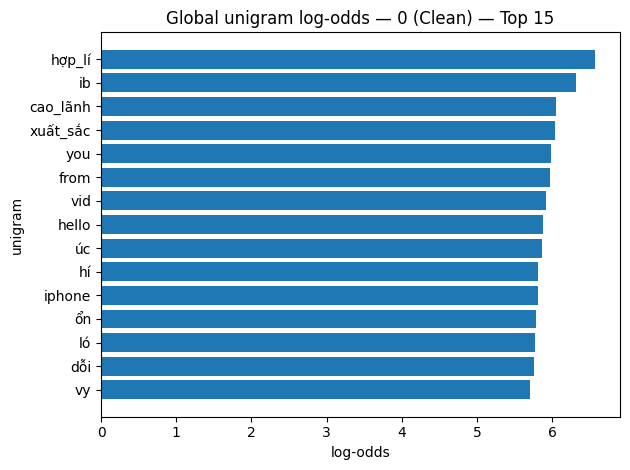

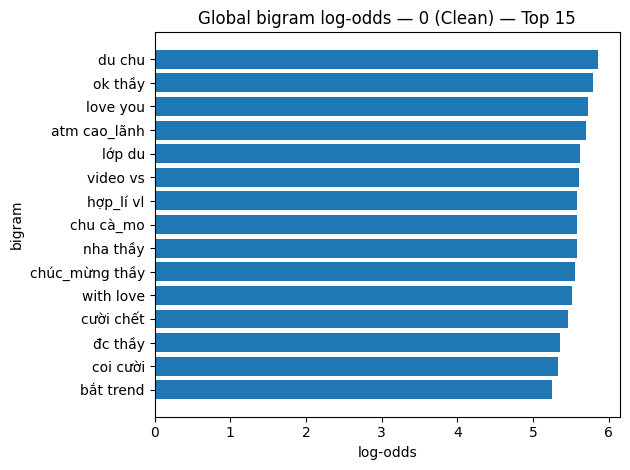

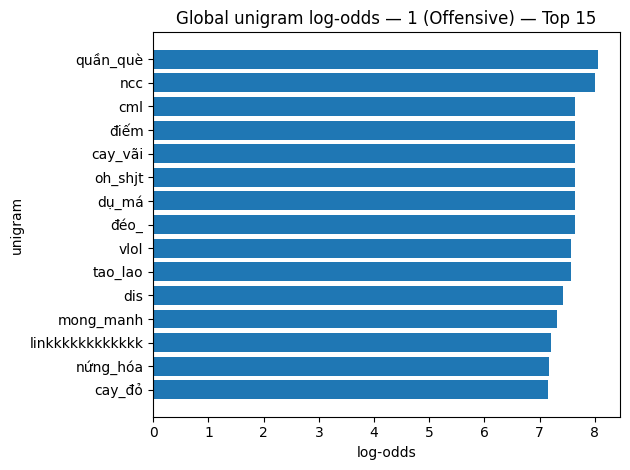

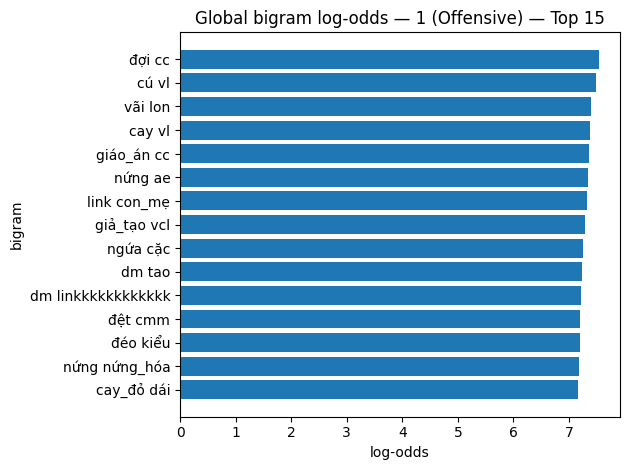

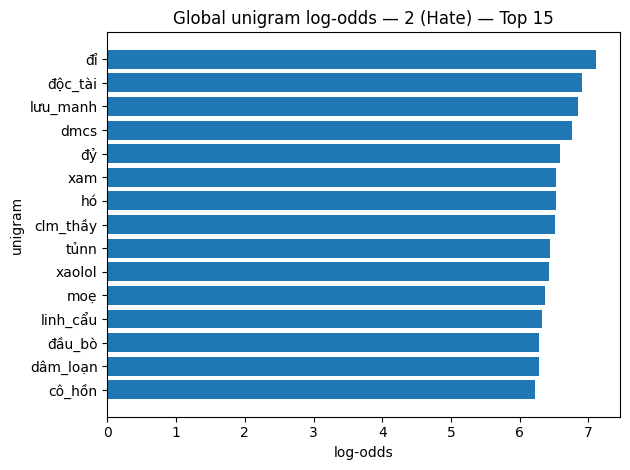

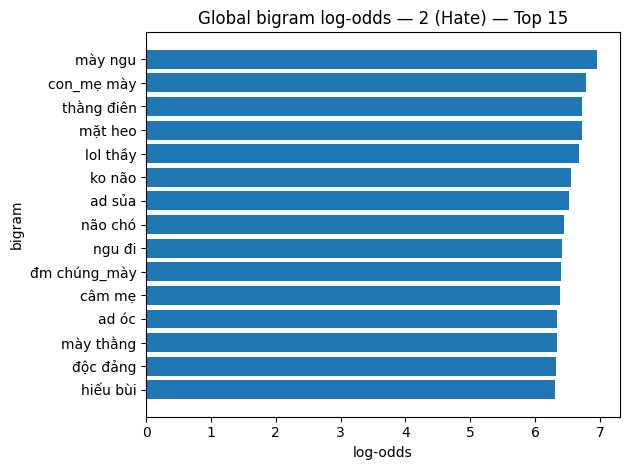


DONE.


In [15]:
# ===================== SHOW TỪNG BƯỚC INFERENCE (1 MẪU MỚI) =====================
# Pipeline: TF-IDF + MultinomialNB (đã train & joblib.dump)
# In ra:
# (1) Input
# (2) Tokenize theo TFIDF (kèm thống kê OOV)
# (3) TF-IDF vector (token/ngram, index, idf, tfidf)
# (4) NB score breakdown: prior + evidence -> score (KHÔNG in proba)
# (5) Local explanation: contrib & delta_vs_runner + delta_vs_Clean
# (6) Global word weights: VẼ biểu đồ log-odds top-K cho từng class
#     -> TÁCH RIÊNG UNIGRAM và BIGRAM (mỗi class 2 hình, không subplot)

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODEL_PATH = "/home/uit2023/LuuTru/Thuchd/cs221/CS221_NLP_SA/models/final_best_mnb_tfidf.joblib"
LABEL_NAME = {0: "Clean", 1: "Offensive", 2: "Hate"}


def _topk_by_mask(values: np.ndarray, mask: np.ndarray, k: int) -> np.ndarray:
    """Return indices of top-k values among positions where mask==True."""
    cand = np.where(mask)[0]
    if cand.size == 0:
        return np.array([], dtype=int)
    k = min(k, cand.size)
    # partial sort for speed, then exact sort on selected
    sel = cand[np.argpartition(values[cand], -k)[-k:]]
    sel = sel[np.argsort(values[sel])[::-1]]
    return sel


def show_one_sample(
    text_new: str,
    topk_local: int = 15,
    topk_global_uni: int = 15,
    topk_global_bi: int = 15,
    plot_global: bool = True,
    save_dir: str | None = "./figs"
):
    # -------------------- Load pipeline --------------------
    pipe = joblib.load(MODEL_PATH)
    tfidf = pipe.named_steps["tfidf"]
    clf   = pipe.named_steps["clf"]

    print("=" * 90)
    print("0) LOAD PIPELINE OK")
    print("TFIDF params:", {k: getattr(tfidf, k) for k in ["analyzer", "ngram_range", "min_df", "max_df", "max_features"] if hasattr(tfidf, k)})
    print("NB params   :", {"alpha": float(clf.alpha), "fit_prior": clf.fit_prior})
    print("Labels      :", LABEL_NAME)
    print("=" * 90)

    # -------------------- 1) INPUT --------------------
    print("\n1) INPUT")
    print("Text:", text_new)

    # -------------------- 2) TOKENIZE --------------------
    analyzer_fn = tfidf.build_analyzer()
    tokens = analyzer_fn(text_new)

    vocab = getattr(tfidf, "vocabulary_", {})
    tokens_in_vocab = [t for t in tokens if t in vocab]
    oov_tokens = [t for t in tokens if t not in vocab]

    print("\n2) TOKENIZE (theo TFIDF.build_analyzer())")
    print("Num tokens/ngrams:", len(tokens))
    print("In-vocab tokens  :", len(tokens_in_vocab))
    print("Out-Of-Vocabulary tokens:", len(oov_tokens))
    print("First tokens     :", tokens[:min(30, len(tokens))])
    if len(oov_tokens) > 0:
        print("First OOV tokens :", oov_tokens[:min(20, len(oov_tokens))])

    # -------------------- 3) TF-IDF VECTOR --------------------
    X = tfidf.transform([text_new])  # shape (1, V)
    feat = tfidf.get_feature_names_out()

    idx = X.nonzero()[1]
    vals = np.array([X[0, j] for j in idx], dtype=float)

    if hasattr(tfidf, "idf_"):
        idf_vals = tfidf.idf_[idx]
    else:
        idf_vals = np.ones_like(vals)

    df_tfidf = pd.DataFrame({
        "feature(token/ngram)": feat[idx],
        "vocab_index": idx,
        "idf": idf_vals,
        "tfidf(x_i)": vals,
    }).sort_values("tfidf(x_i)", ascending=False)

    print("\n3) TF-IDF VECTOR (chỉ show các feature xuất hiện trong câu & có trong vocab)")
    print(df_tfidf.head(30).to_string(index=False))

    # -------------------- 4) NB SCORES (NO PROBA) --------------------
    prior_log = clf.class_log_prior_.copy()  # (C,)
    evidence_log = np.asarray(X @ clf.feature_log_prob_.T).ravel()  # (C,)
    score_log = prior_log + evidence_log  # (C,)

    df_scores = pd.DataFrame({
        "class": list(range(len(score_log))),
        "label": [LABEL_NAME.get(i, str(i)) for i in range(len(score_log))],
        "prior_log=logP(c)": prior_log,
        "evidence_log=sum(x_i*logP(w|c))": evidence_log,
        "score_log=prior+evidence": score_log,
    }).sort_values("score_log=prior+evidence", ascending=False)

    pred = int(score_log.argmax())
    runner = int(score_log.argsort()[-2])
    clean = 0  # Clean class id

    print("\n4) MULTINOMIAL NB SCORES — BREAKDOWN (NO PROBA)")
    print(df_scores.to_string(index=False))
    print(f"=> PREDICTED: {pred} ({LABEL_NAME.get(pred, pred)}) | runner-up: {runner} ({LABEL_NAME.get(runner, runner)})")

    # -------------------- 5) LOCAL EXPLANATION --------------------
    logP_pred  = clf.feature_log_prob_[pred, idx]
    logP_run   = clf.feature_log_prob_[runner, idx]
    logP_clean = clf.feature_log_prob_[clean, idx]

    contrib_pred  = vals * logP_pred
    contrib_run   = vals * logP_run
    contrib_clean = vals * logP_clean

    delta_vs_runner = vals * (logP_pred - logP_run)
    delta_vs_clean  = vals * (logP_pred - logP_clean)

    df_local = pd.DataFrame({
        "feature(token/ngram)": feat[idx],
        "tfidf(x_i)": vals,

        f"logP(w|{LABEL_NAME.get(pred, pred)})": logP_pred,
        f"logP(w|{LABEL_NAME.get(runner, runner)})": logP_run,
        "logP(w|Clean)": logP_clean,

        f"contrib_{LABEL_NAME.get(pred, pred)}": contrib_pred,
        f"contrib_{LABEL_NAME.get(runner, runner)}": contrib_run,
        "contrib_Clean": contrib_clean,

        f"delta_vs_{LABEL_NAME.get(runner, runner)}": delta_vs_runner,
        "delta_vs_Clean": delta_vs_clean,
    }).sort_values(f"delta_vs_{LABEL_NAME.get(runner, runner)}", ascending=False)

    print("\n5) LOCAL EXPLANATION (top token/ngram giúp pred thắng runner-up + so với Clean)")
    print(f"(pred={pred}:{LABEL_NAME.get(pred)}, runner-up={runner}:{LABEL_NAME.get(runner)}, Clean={clean}:{LABEL_NAME.get(clean)})")
    print(df_local.head(topk_local).to_string(index=False))

    # -------------------- 6) GLOBAL WORD WEIGHTS (PLOT, split unigram/bigram) --------------------
    if plot_global:
        print("\n6) GLOBAL WORD WEIGHTS (PLOT by LOG-ODDS) — SPLIT UNIGRAM/BIGRAM")

        logpw = clf.feature_log_prob_  # (C, V)
        C, V = logpw.shape

        # unigram: không có space; bigram: có space
        is_bigram = np.array([(" " in t) for t in feat], dtype=bool)
        is_unigram = ~is_bigram

        for c in range(C):
            others_mean = np.delete(logpw, c, axis=0).mean(axis=0)
            logodds = logpw[c] - others_mean  # (V,)

            # ---- Unigram top-k ----
            top_u = _topk_by_mask(logodds, is_unigram, topk_global_uni)
            if top_u.size > 0:
                df_u = pd.DataFrame({
                    "token": feat[top_u],
                    "logodds": logodds[top_u]
                }).sort_values("logodds", ascending=True)

                plt.figure()
                plt.barh(df_u["token"], df_u["logodds"])
                plt.xlabel("log-odds")
                plt.ylabel("unigram")
                plt.title(f"Global unigram log-odds — {c} ({LABEL_NAME.get(c, c)}) — Top {min(topk_global_uni, top_u.size)}")
                plt.tight_layout()

                if save_dir is not None:
                    os.makedirs(save_dir, exist_ok=True)
                    out_path = os.path.join(save_dir, f"global_logodds_unigram_class{c}_{LABEL_NAME.get(c, str(c))}.png")
                    plt.savefig(out_path, dpi=200, bbox_inches="tight")
            else:
                print(f"[WARN] No unigram features found for class {c} (unexpected).")

            # ---- Bigram top-k ----
            top_b = _topk_by_mask(logodds, is_bigram, topk_global_bi)
            if top_b.size > 0:
                df_b = pd.DataFrame({
                    "token": feat[top_b],
                    "logodds": logodds[top_b]
                }).sort_values("logodds", ascending=True)

                plt.figure()
                plt.barh(df_b["token"], df_b["logodds"])
                plt.xlabel("log-odds")
                plt.ylabel("bigram")
                plt.title(f"Global bigram log-odds — {c} ({LABEL_NAME.get(c, c)}) — Top {min(topk_global_bi, top_b.size)}")
                plt.tight_layout()

                if save_dir is not None:
                    os.makedirs(save_dir, exist_ok=True)
                    out_path = os.path.join(save_dir, f"global_logodds_bigram_class{c}_{LABEL_NAME.get(c, str(c))}.png")
                    plt.savefig(out_path, dpi=200, bbox_inches="tight")
            else:
                print(f"[WARN] No bigram features found for class {c} (maybe ngram_range=(1,1)).")

        plt.show()

    print("\nDONE.")
    print("=" * 90)


if __name__ == "__main__":
    # Thay câu này bằng mẫu bạn muốn test
    text_new = "lũ ngu vô_học ... viết tiêu_đề sai chính_tả ."
    show_one_sample(
        text_new=text_new,
        topk_local=15,
        topk_global_uni=15,
        topk_global_bi=15,
        plot_global=True,
        save_dir="./figs"
    )
